In [2]:
import cv2
import torch
import os
import xml.etree.ElementTree as ET

image_dir = "../../Data/JPEGImages"
annotation_dir = "../../Data/Annotations"

classes = [
    "aeroplane",
    "bird",
    "boat",
    "car",
    "dog",
    "motorbike",
    "person",
]

images = []
boxes = []
labels = []

for name in os.listdir(image_dir):

    if not name.endswith(".jpg"):
        continue

    xml_path = os.path.join(
        annotation_dir,
        name.replace(".jpg", ".xml")
    )

    root = ET.parse(xml_path).getroot()

    image_boxes = []
    image_labels = []

    for obj in root.findall("object"):

        label = obj.find("name").text

        if label not in classes:
            continue

        box = obj.find("bndbox")

        xmin = int(float(box.find("xmin").text))
        ymin = int(float(box.find("ymin").text))
        xmax = int(float(box.find("xmax").text))
        ymax = int(float(box.find("ymax").text))

        image_boxes.append([
            xmin,
            ymin,
            xmax,
            ymax
        ])

        image_labels.append(label)

    if len(image_boxes) > 0:

        image = cv2.imread(
            os.path.join(image_dir, name)
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        images.append(
            torch.tensor(image)
        )

        boxes.append(
            torch.tensor(image_boxes)
        )

        labels.append(
            image_labels
        )


In [3]:
print(len(images))
print(images[18].shape)
print(boxes[18])
print(labels[18])

13155
torch.Size([375, 500, 3])
tensor([[293, 162, 419, 375],
        [114, 165, 228, 373],
        [  5, 172, 116, 373],
        [  2,  68, 486, 325]])
['person', 'person', 'person', 'aeroplane']


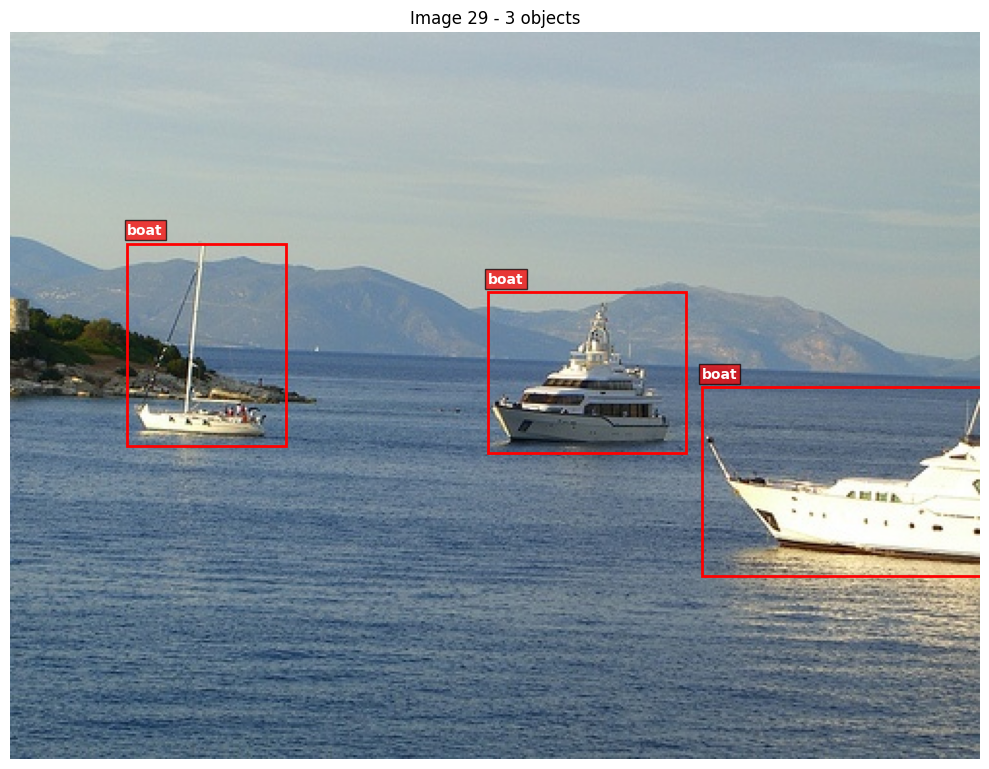

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Image 29 - 3 objects'}>)

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_boxes(image, boxes, labels, title=None, figsize=(10, 10)):
    if hasattr(image, 'permute'):
        if image.shape[0] == 3:
            image = image.permute(1, 2, 0).numpy()
    elif hasattr(image, 'numpy'):
        image = image.numpy()
    
    if image.max() <= 1.0:
        image = (image * 255).astype('uint8')
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    
    colors = [
        'red', 'blue', 'green', 'orange', 'purple', 
        'cyan', 'magenta', 'yellow', 'brown', 'pink',
        'gray'
    ]
    
    label_colors = {label: colors[i % len(colors)] for i, label in enumerate(set(labels))}
    
    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = [int(x) for x in box]
        color = label_colors[label]
        
        ax.add_patch(patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=color, facecolor='none'
        ))
        
        ax.text(xmin, ymin - 5, label, color='white', fontsize=10, weight='bold',
                bbox=dict(facecolor=color, alpha=0.7, pad=2))
    
    if title:
        ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    return fig, ax

visualize_boxes(images[8], boxes[8], labels[8], f"Image 29 - {len(boxes[8])} objects")

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_boxes, val_boxes, train_labels, val_labels = train_test_split(
    images,
    boxes,
    labels,
    test_size=0.2,
    random_state=42
)

In [7]:
train_images[1].shape

torch.Size([375, 500, 3])

In [8]:
def iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])

    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)

    intersection = inter_w * inter_h

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - intersection

    return intersection / union

In [9]:
import selectivesearch
import cv2
import numpy as np

def selective_search(image):

    image = image.copy()

    if hasattr(image, "numpy"):
        image = image.numpy()

    image = image.astype(np.uint8)

    _, regions = selectivesearch.selective_search(
        image,
        scale=1000,
        sigma=1.5,
        min_size=100
    )

    proposals = []

    for region in regions:

        x, y, w, h = region["rect"]

        if w < 30 or h < 30:
            continue

        proposals.append([
            x,
            y,
            x + w,
            y + h
        ])

    return proposals


In [10]:
def match_proposals(proposals, gt_boxes, gt_labels):

    proposal_labels = []
    proposal_ious = []

    for proposal in proposals:

        best_iou = 0
        best_label = "background"

        for gt_box, gt_label in zip(gt_boxes, gt_labels):

            score = iou(proposal, gt_box)

            if score > best_iou:
                best_iou = score
                best_label = gt_label

        if best_iou < 0.5:
            best_label = "background"

        proposal_labels.append(best_label)
        proposal_ious.append(best_iou)

    return proposal_labels, proposal_ious

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Number of proposals: 33


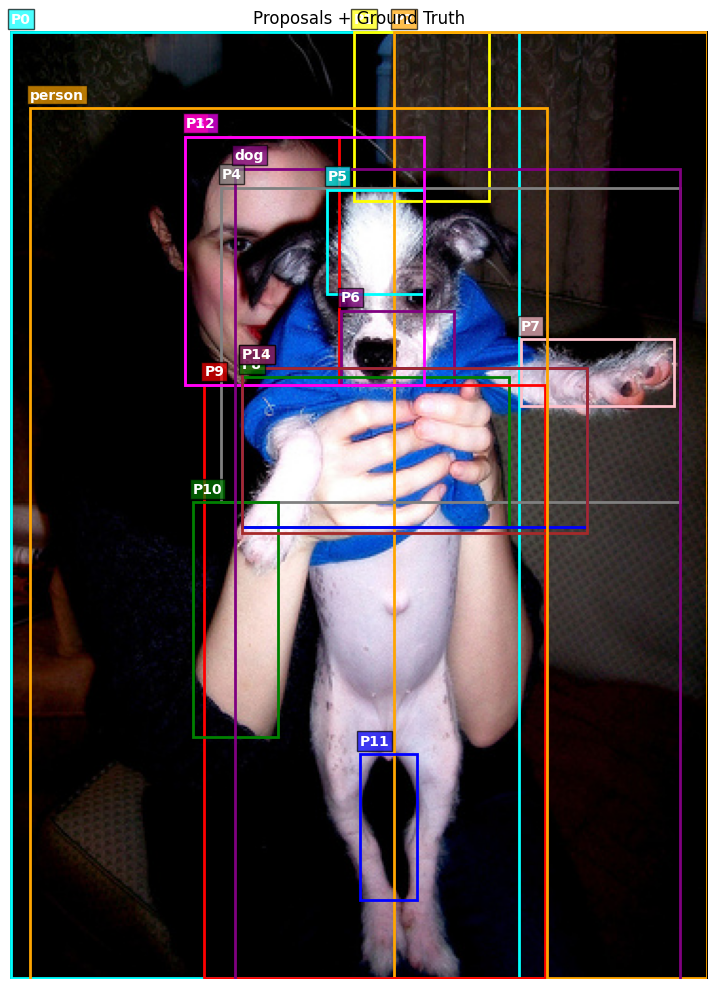

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Proposals + Ground Truth'}>)

In [11]:
image = train_images[15].numpy()

proposals = selective_search(image)

print("Number of proposals:", len(proposals))

gt_boxes = train_boxes[15].tolist()
gt_labels = train_labels[15]

boxes_to_show = proposals[:15] + gt_boxes

labels_to_show = (
    [f"P{i}" for i in range(15)]
    + gt_labels
)

visualize_boxes(
    image,
    boxes_to_show,
    labels_to_show,
    title="Proposals + Ground Truth"
)

Total proposals: 33
Best proposal:
Index: 20
Box: [92, 55, 353, 499]
Label: dog
IoU: tensor(0.8642)


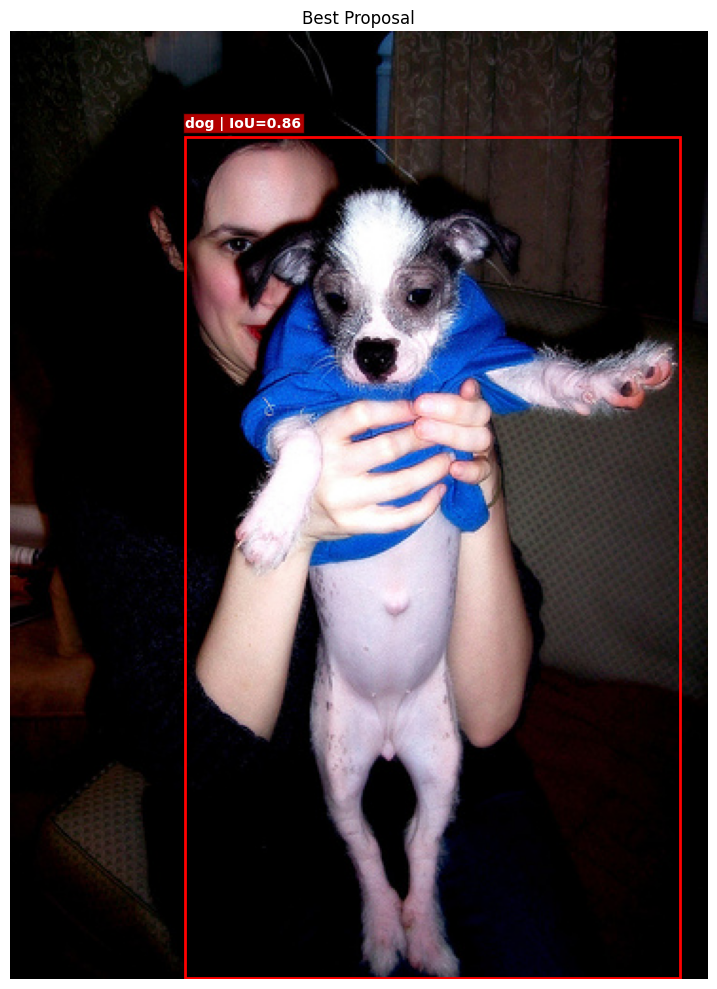

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Best Proposal'}>)

In [12]:
proposal_labels, proposal_ious = match_proposals(
    proposals,
    train_boxes[15],
    train_labels[15]
)

print("Total proposals:", len(proposals))

best_i = np.argmax(proposal_ious)

print("Best proposal:")
print("Index:", best_i)
print("Box:", proposals[best_i])
print("Label:", proposal_labels[best_i])
print("IoU:", proposal_ious[best_i])

visualize_boxes(
    image,
    [proposals[best_i]],
    [f"{proposal_labels[best_i]} | IoU={proposal_ious[best_i]:.2f}"],
    title="Best Proposal"
)

In [13]:
import cv2
import torch
import numpy as np

def prepare_proposals(image, proposals, size=128):

    crops = []

    for box in proposals:

        xmin, ymin, xmax, ymax = [int(x) for x in box]

        # Crop
        crop = image[ymin:ymax, xmin:xmax]

        if crop.size == 0:
            continue

        # Resize
        crop = cv2.resize(
            crop,
            (size, size)
        )

        # numpy → tensor
        crop = torch.tensor(crop)

        # H,W,C → C,H,W
        crop = crop.permute(2, 0, 1)

        # 0-255 → 0-1
        crop = crop.float() / 255.0

        crops.append(crop)

    # N,C,H,W
    return torch.stack(crops)

In [14]:
image = train_images[133].numpy()

proposals = selective_search(image)

proposal_labels, proposal_ious = match_proposals(
    proposals,
    train_boxes[133],
    train_labels[133]
)

proposal_images = prepare_proposals(
    image,
    proposals
)

print("Proposals:", len(proposals))
print("Prepared:", proposal_images.shape)

Proposals: 29
Prepared: torch.Size([29, 3, 128, 128])


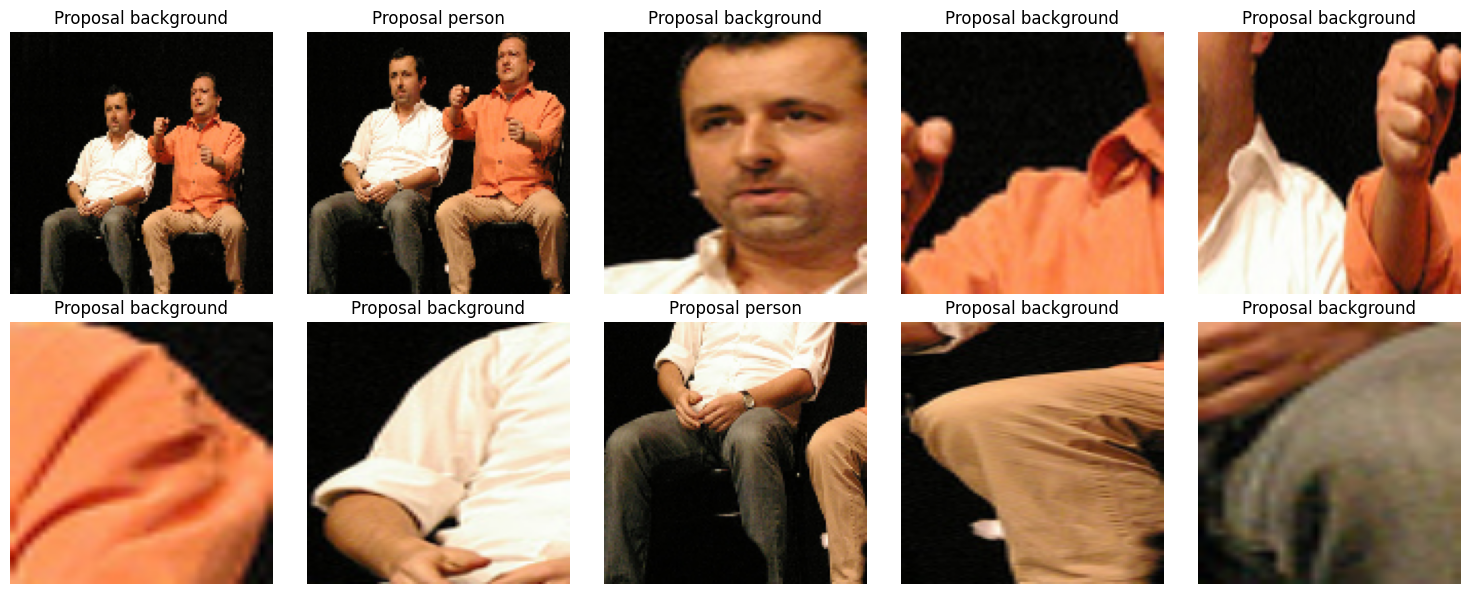

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        proposal_images[i].permute(1, 2, 0)
    )

    plt.title(f"Proposal {proposal_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
class_to_idx = {
    "background": 0,
    "aeroplane": 1,
    "bird": 2,
    "boat": 3,
    "bottle": 4,
    "car": 5,
    "cat": 6,
    "chair": 7,
    "diningtable": 8,
    "dog": 9,
    "motorbike": 10,
    "person": 11
}


In [ ]:
train_proposal_images = []
train_proposal_labels = []

for i in range(len(train_images)):

    image = train_images[i].numpy()

    proposals = selective_search(image)[:10]

    proposal_labels, proposal_ious = match_proposals(
        proposals,
        train_boxes[i],
        train_labels[i]
    )

    proposal_images = prepare_proposals(
        image,
        proposals
    )

    for proposal_image, label, score in zip(
        proposal_images,
        proposal_labels,
        proposal_ious
    ):

        train_proposal_images.append(proposal_image)

        train_proposal_labels.append(
            class_to_idx[label]
        )

X_train_rcnn = torch.stack(train_proposal_images)

y_train_rcnn = torch.tensor(
    train_proposal_labels,
    dtype=torch.long
)

In [ ]:
val_proposal_images = []
val_proposal_labels = []

for i in range(len(val_images)):

    image = val_images[i].numpy()

    proposals = selective_search(image)

    proposal_labels, proposal_ious = match_proposals(
        proposals,
        val_boxes[i],
        val_labels[i]
    )

    proposal_images = prepare_proposals(
        image,
        proposals
    )

    for proposal_image, label, score in zip(
        proposal_images,
        proposal_labels,
        proposal_ious
    ):

        if score < 0.4:
            continue

        val_proposal_images.append(
            proposal_image
        )

        val_proposal_labels.append(
            class_to_idx[label]
        )


X_val_rcnn = torch.stack(
    val_proposal_images
)

y_val_rcnn = torch.tensor(
    val_proposal_labels,
    dtype=torch.long
)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_rcnn,
    y_train_rcnn
)

val_dataset = TensorDataset(
    X_val_rcnn,
    y_val_rcnn
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
val_proposal_images = []
val_proposal_labels = []

for i in range(len(val_images)):

    image = val_images[i].numpy()

    proposals = selective_search(image)

    proposal_labels, proposal_ious = match_proposals(
        proposals,
        val_boxes[i],
        val_labels[i]
    )

    proposal_images = prepare_proposals(
        image,
        proposals
    )

    for proposal_image, label, score in zip(
        proposal_images,
        proposal_labels,
        proposal_ious
    ):

        if score < 0.4:
            continue

        val_proposal_images.append(
            proposal_image
        )

        val_proposal_labels.append(
            class_to_idx[label]
        )


X_val_rcnn = torch.stack(
    val_proposal_images
)

y_val_rcnn = torch.tensor(
    val_proposal_labels,
    dtype=torch.long
)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train_rcnn,
    y_train_rcnn
)

val_dataset = TensorDataset(
    X_val_rcnn,
    y_val_rcnn
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)